<a href="https://colab.research.google.com/github/DaniyahSajid/Mini-Project-4th-SEM/blob/main/Tomato_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d ashishmotwani/tomato
!unzip tomato.zip -d /content/tomato_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/tomato_dataset/valid/Late_blight/9aaf4a7d-12ac-457a-a18c-1f7ea13065de___RS_Late.B 5179.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9afc2537-1b13-4c25-b5ed-5b8de511b0ab___GHLB2 Leaf 9033.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9bb49d22-976d-40c3-bc9a-bff5cbbd8e28___RS_Late.B 5057.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9c274db5-2f89-4f3c-b9e2-4d5ebc54ddad___GHLB2 Leaf 9096.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9c726f4e-045b-4080-b53d-d7e66d45bcb1___RS_Late.B 4876.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9e5dd34f-124c-4a64-ba9f-77c8d05faa9c___GHLB2 Leaf 8749.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9e633823-3dde-450c-8172-733021e4dff0___RS_Late.B 6414.JPG  
  inflating: /content/tomato_dataset/valid/Late_blight/9ecb8001-2f48-4487-b287-535dbcfb5c2f___RS_Late.B 6206.JPG  
  inflating: /content/toma

In [ ]:
import os
os.listdir("/content/tomato_dataset")

['train', 'valid']

In [ ]:
import os

train_path = "/content/tomato_dataset/train"
valid_path = "/content/tomato_dataset/valid"

train_classes = os.listdir(train_path)
valid_classes = os.listdir(valid_path)

print("Train Classes:", train_classes)
print("Valid Classes:", valid_classes)

# Count images per class
for cls in train_classes:
    print(f"Class: {cls}, Train Images: {len(os.listdir(os.path.join(train_path, cls)))}")

Train Classes: ['Early_blight', 'healthy', 'Tomato_mosaic_virus', 'Septoria_leaf_spot', 'Leaf_Mold', 'Late_blight', 'Bacterial_spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'powdery_mildew', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot']
Valid Classes: ['Early_blight', 'healthy', 'Tomato_mosaic_virus', 'Septoria_leaf_spot', 'Leaf_Mold', 'Late_blight', 'Bacterial_spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'powdery_mildew', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot']
Class: Early_blight, Train Images: 2455
Class: healthy, Train Images: 3051
Class: Tomato_mosaic_virus, Train Images: 2153
Class: Septoria_leaf_spot, Train Images: 2882
Class: Leaf_Mold, Train Images: 2754
Class: Late_blight, Train Images: 3113
Class: Bacterial_spot, Train Images: 2826
Class: Tomato_Yellow_Leaf_Curl_Virus, Train Images: 2039
Class: powdery_mildew, Train Images: 1004
Class: Spider_mites Two-spotted_spider_mite, Train Images: 1747
Class: Target_Spot, Train Images: 1827


In [ ]:
!pip install opencv-python numpy scikit-image

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import matplotlib.pyplot as plt

# Dataset Path
dataset_path = "/content/tomato_dataset/train"

# Get class names
classes = os.listdir(dataset_path)
print("Classes:", classes)

# Function to load an image
def load_image(class_name, img_name):
    img_path = os.path.join(dataset_path, class_name, img_name)
    img = cv2.imread(img_path)  # Load image
    img = cv2.resize(img, (128, 128))  # Resize for consistency
    return img

Classes: ['Early_blight', 'healthy', 'Tomato_mosaic_virus', 'Septoria_leaf_spot', 'Leaf_Mold', 'Late_blight', 'Bacterial_spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'powdery_mildew', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot']


In [ ]:
def extract_color_features(img):
    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Compute color histograms
    hist_rgb = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256]).flatten()
    hist_hsv = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256]).flatten()

    return np.hstack([hist_rgb, hist_hsv])

In [ ]:
def extract_texture_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return np.array([contrast, dissimilarity, homogeneity, energy, correlation])

In [ ]:
def extract_shape_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    edge_pixels = np.sum(edges) / 255
    total_pixels = gray.size
    edge_density = edge_pixels / total_pixels  # Percentage of edges

    return np.array([edge_density])


In [ ]:
def extract_features(img):
    color_features = extract_color_features(img)
    texture_features = extract_texture_features(img)
    shape_features = extract_shape_features(img)

    return np.hstack([color_features, texture_features, shape_features])


In [ ]:
import pandas as pd

data = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_path):
        img = load_image(class_name, img_name)
        features = extract_features(img)
        data.append(features)
        labels.append(class_name)

# Convert to DataFrame
df = pd.DataFrame(data)
df["label"] = labels
print(df.head())


        0     1    2    3    4    5    6    7       8      9  ...  1021  1022  \
0   184.0  56.0  0.0  0.0  0.0  0.0  0.0  0.0   218.0  606.0  ...   0.0   0.0   
1   360.0  78.0  0.0  0.0  0.0  0.0  0.0  0.0   524.0  428.0  ...   0.0   0.0   
2    38.0  18.0  0.0  0.0  0.0  0.0  0.0  0.0  1272.0  400.0  ...   0.0   0.0   
3   310.0  30.0  0.0  0.0  0.0  0.0  0.0  0.0   157.0  156.0  ...   0.0   0.0   
4  2614.0  12.0  0.0  0.0  0.0  0.0  0.0  0.0   137.0  123.0  ...   0.0   0.0   

   1023        1024       1025      1026      1027      1028      1029  \
0   0.0  180.554564   8.642901  0.171514  0.023561  0.949240  0.151550   
1   0.0  216.329601   8.730807  0.201937  0.018804  0.959553  0.142395   
2   0.0   95.693406   6.819882  0.154774  0.026324  0.944313  0.063538   
3   0.0  104.699557   6.665477  0.194622  0.021443  0.971068  0.068787   
4   0.0  268.749200  10.587291  0.204006  0.050684  0.960895  0.115112   

          label  
0  Early_blight  
1  Early_blight  
2  Early_bligh

In [ ]:
df.to_csv("/content/tomato_features.csv", index=False)
print("Feature extraction complete! ")


Feature extraction complete! 🚀


In [ ]:
import pandas as pd

# Load extracted features
df = pd.read_csv("/content/tomato_features.csv")

# Separate features (X) and labels (y)
X = df.drop(columns=["label"])  # Features
y = df["label"]                 # Target variable (disease labels)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode class labels as numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert labels to numbers

# Save mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'Bacterial_spot': 0, 'Early_blight': 1, 'Late_blight': 2, 'Leaf_Mold': 3, 'Septoria_leaf_spot': 4, 'Spider_mites Two-spotted_spider_mite': 5, 'Target_Spot': 6, 'Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato_mosaic_virus': 8, 'healthy': 9, 'powdery_mildew': 10}


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")


Training Samples: 20680 | Testing Samples: 5171


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Accuracy on training data
rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = rf_model.score(X_test, y_test)

print(f"Random Forest - Training Accuracy: {rf_train_acc:.4f}")
print(f"Random Forest - Testing Accuracy: {rf_test_acc:.4f}")


Random Forest - Training Accuracy: 0.9999
Random Forest - Testing Accuracy: 0.9635


In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="mlogloss", random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Accuracy on training data
xgb_train_acc = xgb_model.score(X_train, y_train)
xgb_test_acc = xgb_model.score(X_test, y_test)

print(f"XGBoost - Training Accuracy: {xgb_train_acc:.4f}")
print(f"XGBoost - Testing Accuracy: {xgb_test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:41:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Training Accuracy: 0.9999
XGBoost - Testing Accuracy: 0.9681


In [ ]:
from sklearn.ensemble import VotingClassifier

# Create the Hybrid Model
hybrid_model = VotingClassifier(
    estimators=[("RandomForest", rf_model), ("XGBoost", xgb_model)],
    voting="soft"  # Soft voting averages probability predictions
)

# Train the Hybrid Model
hybrid_model.fit(X_train, y_train)

# Accuracy on training data
hybrid_train_acc = hybrid_model.score(X_train, y_train)
hybrid_test_acc = hybrid_model.score(X_test, y_test)

print(f"Hybrid Model - Training Accuracy: {hybrid_train_acc:.4f}")
print(f"Hybrid Model - Testing Accuracy: {hybrid_test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:44:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Hybrid Model - Training Accuracy: 0.9999
Hybrid Model - Testing Accuracy: 0.9685


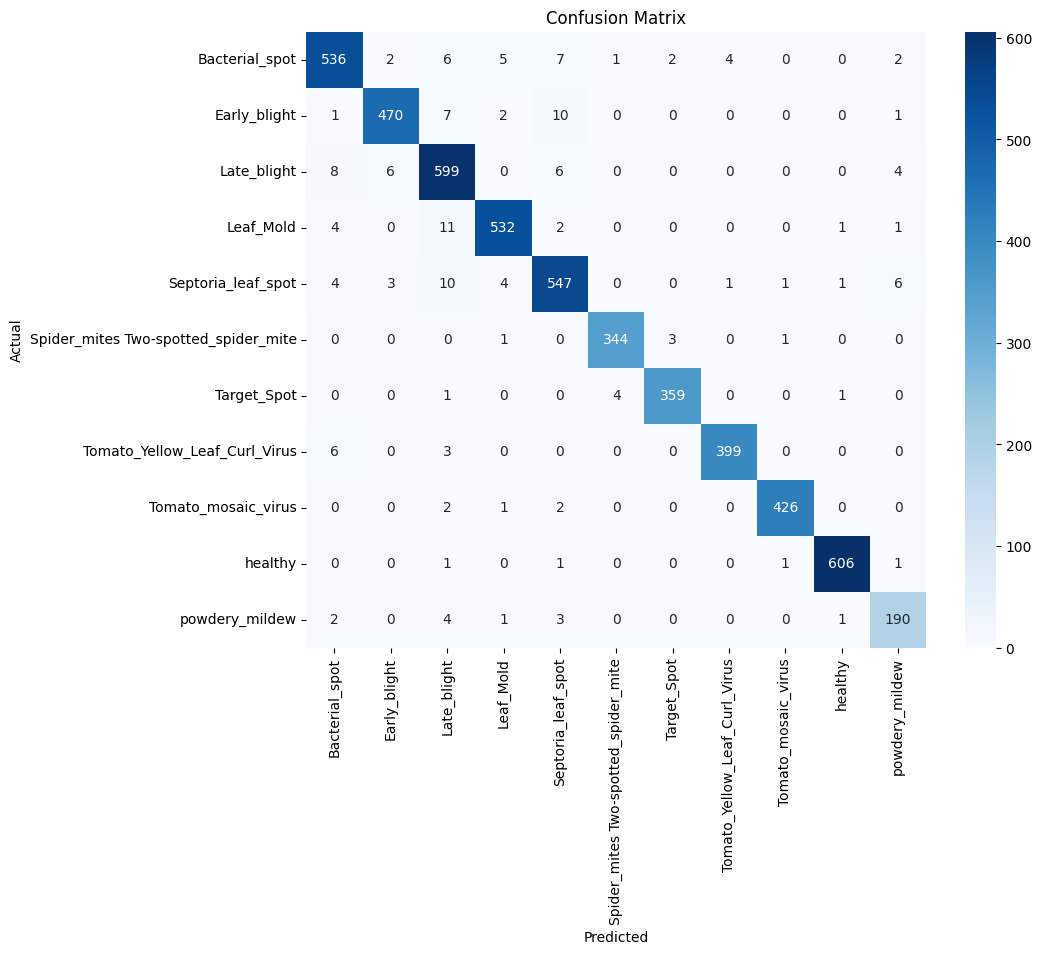

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = hybrid_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate report
report = classification_report(y_test, y_pred, target_names=label_mapping.keys())

print("Classification Report:\n", report)


Classification Report:
                                       precision    recall  f1-score   support

                      Bacterial_spot       0.96      0.95      0.95       565
                        Early_blight       0.98      0.96      0.97       491
                         Late_blight       0.93      0.96      0.95       623
                           Leaf_Mold       0.97      0.97      0.97       551
                  Septoria_leaf_spot       0.95      0.95      0.95       577
Spider_mites Two-spotted_spider_mite       0.99      0.99      0.99       349
                         Target_Spot       0.99      0.98      0.98       365
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.98      0.98       408
                 Tomato_mosaic_virus       0.99      0.99      0.99       431
                             healthy       0.99      0.99      0.99       610
                      powdery_mildew       0.93      0.95      0.94       201

                            accuracy  

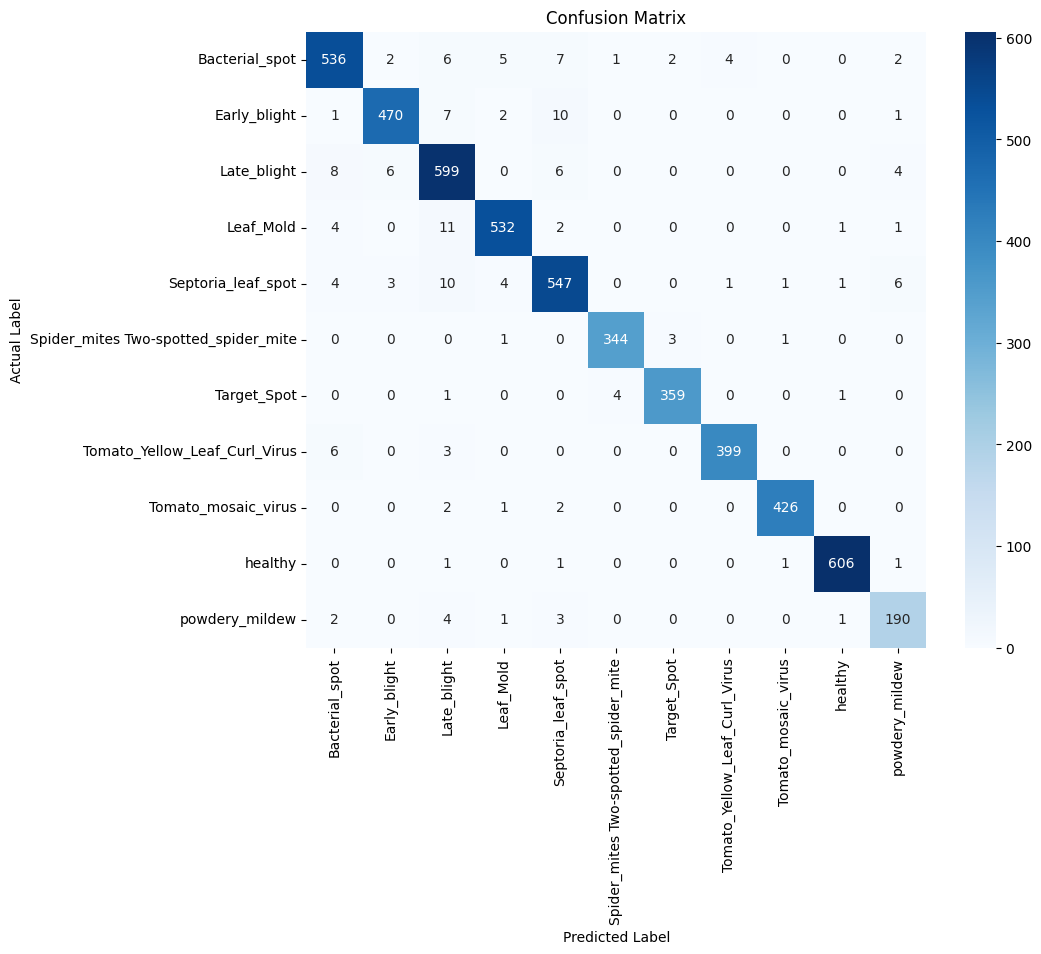

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = hybrid_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Grid search
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=3, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

# Best parameters
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)

# Train with best parameters
best_rf = grid_search_rf.best_estimator_


Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a smaller parameter grid to speed up tuning
param_grid_xgb = {
    'n_estimators': [100, 300],  # Reduced options
    'max_depth': [3, 6],  # Fewer depth choices
    'learning_rate': [0.01, 0.1],  # Limited learning rates
    'subsample': [0.7, 1.0],  # Two choices instead of three
    'colsample_bytree': [0.7, 1.0],  # Two choices instead of three
}

# Initialize XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Perform RandomizedSearchCV with reduced iterations and folds
random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=5,  # Reduced from 10 to 5
    cv=2,  # Reduced from 3 to 2
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit the model
random_search_xgb.fit(X_train, y_train)

# Print best parameters
print("Best Parameters for XGBoost:", random_search_xgb.best_params_)

# Train final XGBoost model with best parameters
best_xgb = random_search_xgb.best_estimator_


Fitting 2 folds for each of 5 candidates, totalling 10 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:39:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [ ]:
from sklearn.ensemble import VotingClassifier
hybrid_model = VotingClassifier(estimators=[
    ('rf', best_rf),
    ('xgb', best_xgb)
], voting='soft')
hybrid_model.fit(X_train, y_train)
hybrid_accuracy = hybrid_model.score(X_test, y_test)
print("Hybrid Model - New Accuracy:", hybrid_accuracy)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:02:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Hybrid Model - New Accuracy: 0.9704119125894412


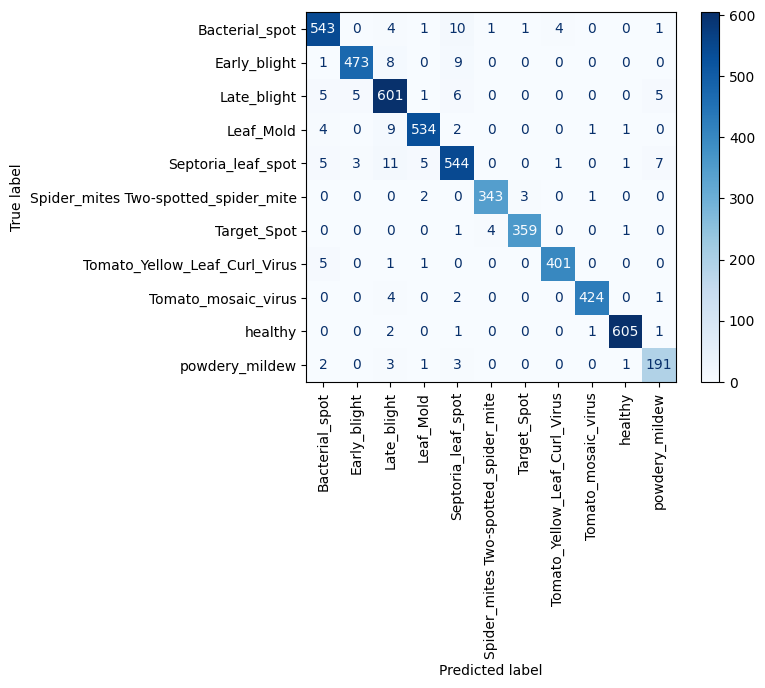

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, hybrid_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.keys())
disp.plot(cmap='Blues', xticks_rotation='vertical')

In [ ]:
from sklearn.metrics import classification_report

# Define class names (modify based on your dataset)
class_names = [
    "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold", "Septoria_leaf_spot",
    "Spider_mites_Two-spotted_spider_mite", "Target_Spot", "Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_mosaic_virus", "healthy", "powdery_mildew"
]

# Generate classification report
report = classification_report(y_test, hybrid_model.predict(X_test), target_names=class_names)

print(report)


                                      precision    recall  f1-score   support

                      Bacterial_spot       0.96      0.96      0.96       565
                        Early_blight       0.98      0.96      0.97       491
                         Late_blight       0.93      0.96      0.95       623
                           Leaf_Mold       0.98      0.97      0.97       551
                  Septoria_leaf_spot       0.94      0.94      0.94       577
Spider_mites_Two-spotted_spider_mite       0.99      0.98      0.98       349
                         Target_Spot       0.99      0.98      0.99       365
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.98      0.99       408
                 Tomato_mosaic_virus       0.99      0.98      0.99       431
                             healthy       0.99      0.99      0.99       610
                      powdery_mildew       0.93      0.95      0.94       201

                            accuracy                          

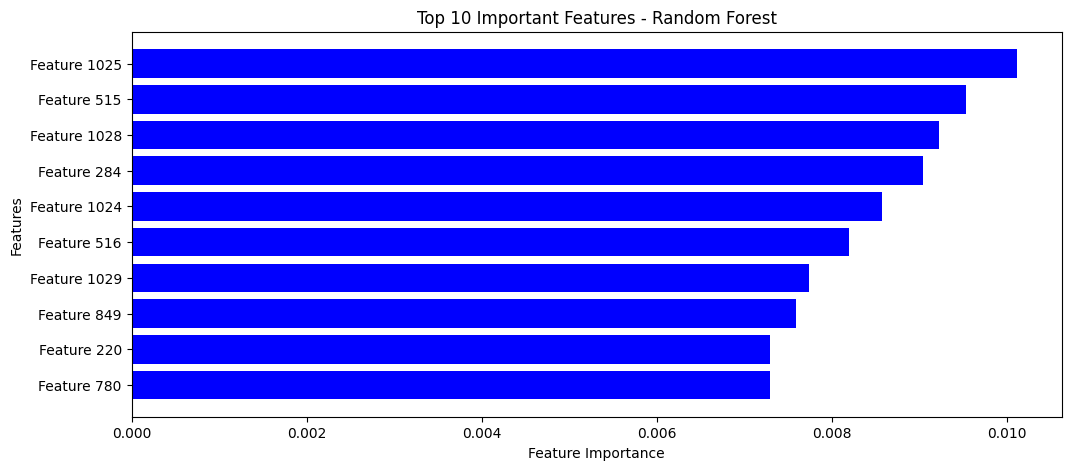

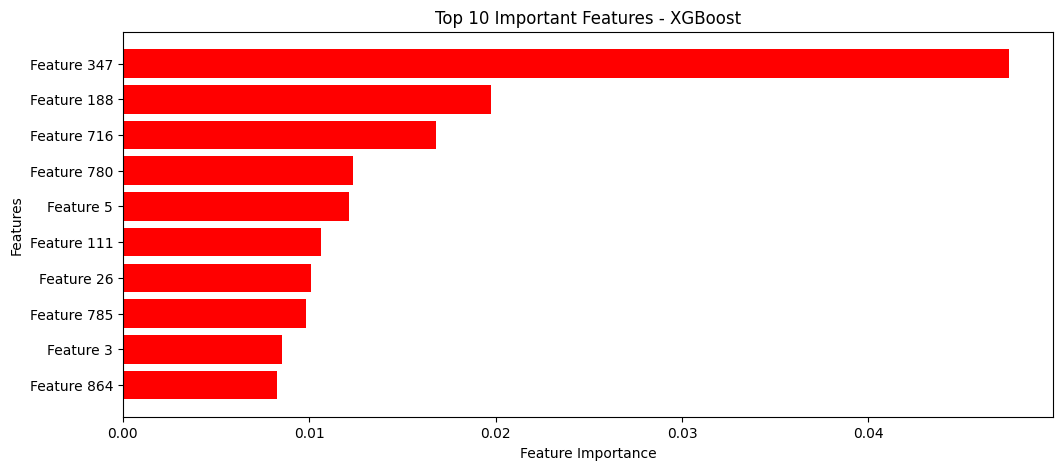

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
rf_importance = best_rf.feature_importances_
xgb_importance = best_xgb.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
rf_sorted_idx = np.argsort(rf_importance)[::-1]
xgb_sorted_idx = np.argsort(xgb_importance)[::-1]
plt.figure(figsize=(12, 5))
plt.barh(np.array(feature_names)[rf_sorted_idx][:10], rf_importance[rf_sorted_idx][:10], color='blue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()
plt.figure(figsize=(12, 5))
plt.barh(np.array(feature_names)[xgb_sorted_idx][:10], xgb_importance[xgb_sorted_idx][:10], color='red')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - XGBoost")
plt.gca().invert_yaxis()
plt.show()